In [1]:
# Importing required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, auc
#from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

In [2]:
# Load the dataset
df = pd.read_csv("C:/Users/chris/Documents/Projects/Data/creditcard.csv")

# Initial review of the dataset
print(f"Dataset shape: {df.shape}\n")

print("Data Schema:")
df.info()


print("Preview of the dataset:")
df.head(10)

Dataset shape: (284807, 31)

Data Schema:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [10]:
#Examine the dataset for duplicate records
duplicate_count = df.duplicated().sum()
print (f"Number of duplicate records: {duplicate_count}\n")

#Remove duplicate records if any  
df.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {df.shape}\n")

#Examine the dataset for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")    
for col, count in missing_values.items():
    print(f"  {col}: {count}")
print()

#Review class distribution
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100


print("--- Class Distribution ---")
for idx, val in class_counts.items():
    label = "Fraud (1)" if idx == 1 else "Normal (0)"
    print(f"{label}: {val} transactions ({class_percentages[idx]:.3f}%)")

    

Number of duplicate records: 0

Dataset shape after removing duplicates: (283726, 31)

Missing values in each column:
  Time: 0
  V1: 0
  V2: 0
  V3: 0
  V4: 0
  V5: 0
  V6: 0
  V7: 0
  V8: 0
  V9: 0
  V10: 0
  V11: 0
  V12: 0
  V13: 0
  V14: 0
  V15: 0
  V16: 0
  V17: 0
  V18: 0
  V19: 0
  V20: 0
  V21: 0
  V22: 0
  V23: 0
  V24: 0
  V25: 0
  V26: 0
  V27: 0
  V28: 0
  Amount: 0
  Class: 0

--- Class Distribution ---
Normal (0): 283253 transactions (99.833%)
Fraud (1): 473 transactions (0.167%)


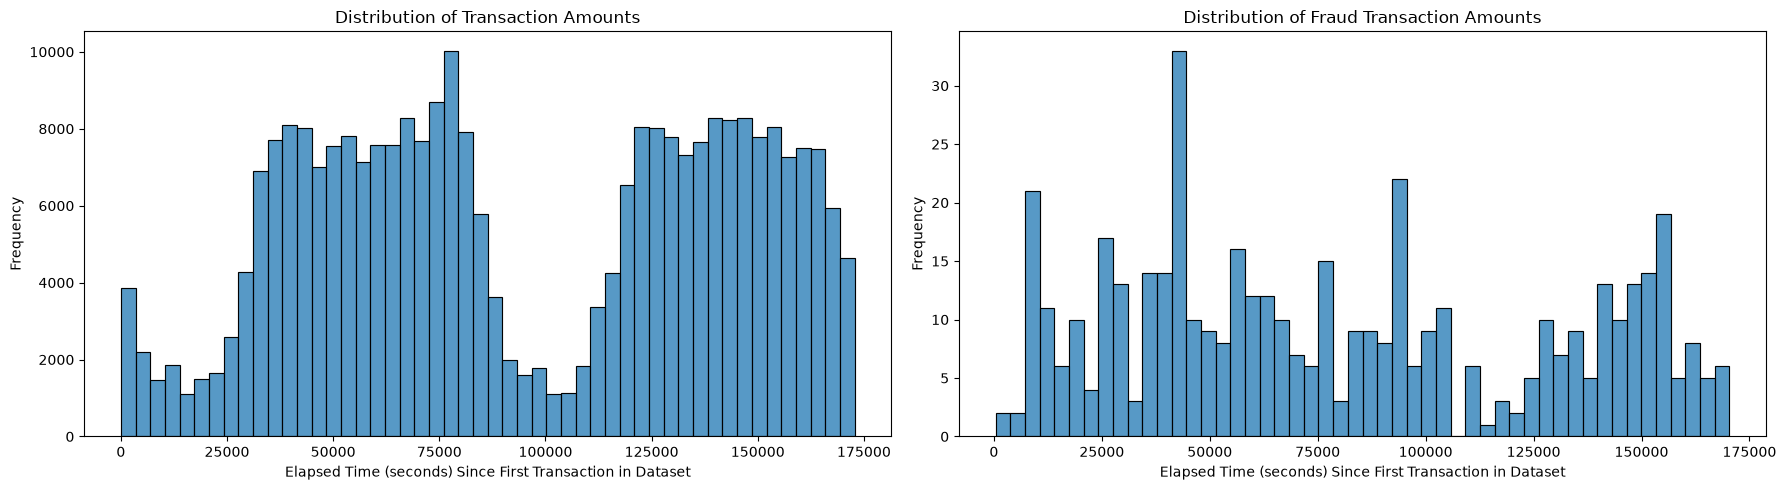

In [ ]:
# Visualize time feature distribution for all transactions and fraud transactions only
fig_time, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=df['Time'], bins=50, ax=axes[0])
axes[0].set_title('Time Distribution of Transaction Amounts')
axes[0].set_xlabel('Elapsed Time (seconds) Since First Transaction in Dataset')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df[df['Class'] == 1]['Time'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Fraud Transaction Amounts')
axes[1].set_xlabel('Elapsed Time (seconds) Since First Transaction in Dataset')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#sns.histplot(x='Amount', data=df, ax=axes[2])

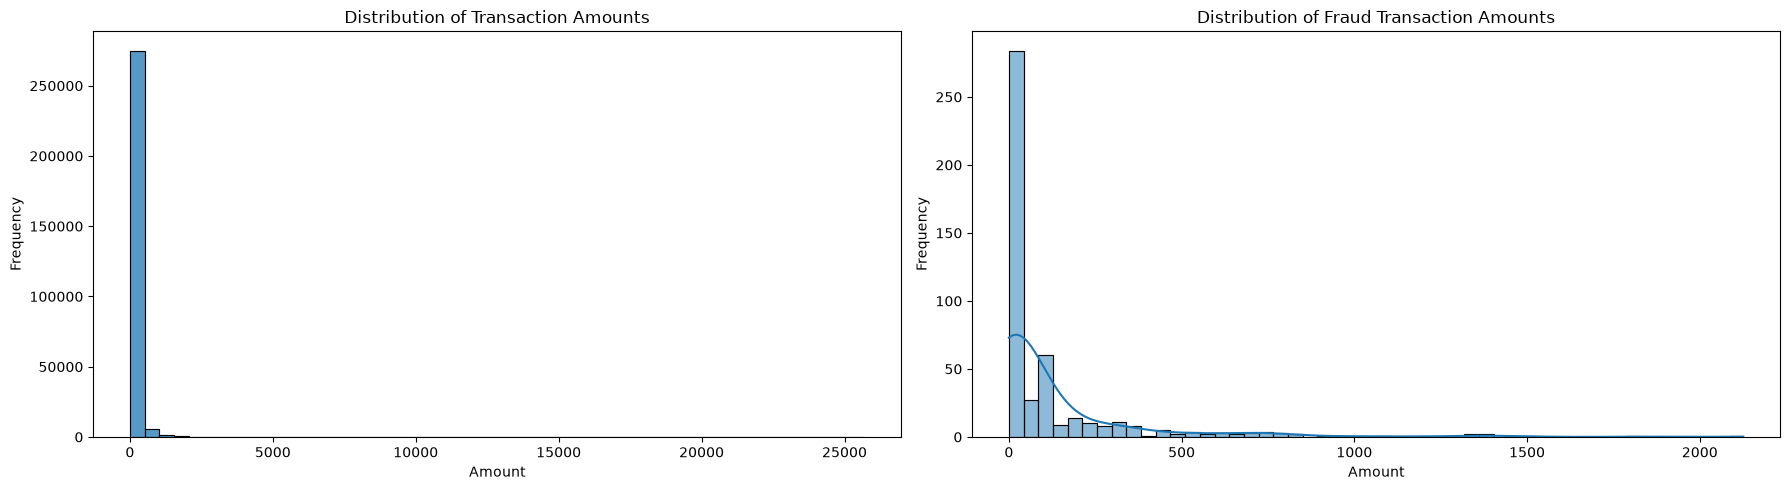

In [19]:
#Visualize amount feature distribution for all transactions and fraud transactions only
fig_amount, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
#axes[0].set_ylim(bottom=0, top=25000)  # Set y-axis to logarithmic scale for better visibility of distribution

sns.histplot(data=df[df['Class'] == 1]['Amount'], bins=50, ax=axes[1], kde=True)
axes[1].set_title('Distribution of Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
#Preparing the data for modeling
# Scaling 'Time' and 'Amount' features
# RobustScaler is used instead of StandardScaler; less sensitive to extreme outliers
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original unscaled columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Insert scaled columns at the beginning of the DataFrame for consistency
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']


KeyError: 'Amount'

In [22]:
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

In [23]:
df

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.295230,1.035258,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0
284803,0.038798,1.035270,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0
284804,0.638020,1.035282,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0
284805,-0.166875,1.035282,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0


In [24]:
# Splitting the dataset into features and target variable
X = df.drop('Class', axis=1)
y = df['Class']     

# Splitting into test and train sets - stratified to maintain class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Train and Test Set Dimensions ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print("\n--- Fraud Ratio in Subsets ---")
print(f"Train Fraud Ratio: {y_train.value_counts(normalize=True)[1]*100:.3f}%")
print(f"Test Fraud Ratio:  {y_test.value_counts(normalize=True)[1]*100:.3f}%")


--- Train and Test Set Dimensions ---
X_train shape: (226980, 30)
X_test shape: (56746, 30)

--- Fraud Ratio in Subsets ---
Train Fraud Ratio: 0.167%
Test Fraud Ratio:  0.167%


In [ ]:
#Initialize model - Random Forest

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

#predict
y_pred = model.predict(X_test)

print(f"--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred))
print("-" * 50 + "\n")

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.79      0.76      0.77        95

    accuracy                           1.00     56746
   macro avg       0.90      0.88      0.89     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------



In [ ]:
# XGBoost Classifier - Baseline model with default hyperparameters
# Calculate the ratio for scale_pos_weight (Negative Class Count / Positive Class Count)
# This acts like class_weight='balanced' for XGBoost and LightGBM
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

model = xgb.XGBClassifier(
        objective='binary:logistic',
    learning_rate=0.1,     
    max_depth=6,            
    n_estimators=100,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='gbtree',    
    tree_method='auto',    
    scale_pos_weight=scale_weight,
    random_state=42) 

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred))
print("-" * 50 + "\n")

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.81      0.82        95

    accuracy                           1.00     56746
   macro avg       0.91      0.91      0.91     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------



In [27]:
# LGB Classifier - Baseline model with default hyperparameters

model = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    max_depth=-1,
    n_estimators=100,
    scale_pos_weight=scale_weight,
    random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"--- LightGBM Classification Report ---")
print(classification_report(y_test, y_pred))
print("-" * 50 + "\n")

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001665 -> initscore=-6.396056
[LightGBM] [Info] Start training from score -6.396056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [ ]:
# Tuning XGBoost Classifier with hyperparameter optimization using GridSearchCV



In [ ]:
#Tuning XGboost Classifier with thresholding

In [ ]:
#Tuning XGBoost Classifier with Bayesian Optimization using Optuna